## 1. Import Libraries and Load Cleaned Data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import RobustScaler, OrdinalEncoder,StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from module_function import (cross_validate_model,plot_all_modelsRegression_predictions,
                             evaluate_models_Regression,feature_importance,plot_residuals,Hyperparameter_Tuning,plot_tuned_feature_importance)

import warnings
warnings.filterwarnings("ignore")

import pickle

In [41]:
df = pd.read_csv('dataset/forestfires_CLEANING.csv')
df_x = df.drop(columns='area')
df_y = df['area']

In [42]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 269 samples
Test set: 68 samples


## 2. Feature Scaling

In [43]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]   
)

## 3.Pipeline All Models Regression

In [44]:
n = 15
regresi_pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', LinearRegression())
    ]),
    
    'Ridge Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Ridge(alpha=0.1))
    ]),
    
    'Lasso Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Lasso(alpha=0.01, random_state=42, max_iter=10000))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42))
    ]),
    
    'XGBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42))
    ]),
    
    'Neural Network (MLP)': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', MLPRegressor(hidden_layer_sizes=(32, 16), activation='relu', solver='adam',alpha=0.1,max_iter=2000, random_state=42))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [45]:
predictions_dict = {}
for model_name, pipeline in regresi_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evaluate_models_Regression( model_dict=predictions_dict, y_test=y_test)
df_report.sort_values(by='R2-Score', ascending=False)

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor
Menguji model: Neural Network (MLP)

Proses Training Selesai!


,Model,R2-Score,MAE,MSE,RMSE
2,Lasso Regression,-0.1154,1.0186,1.4142,1.1892
1,Ridge Regression,-0.1496,1.0311,1.4576,1.2073
0,Linear Regression,-0.1508,1.0312,1.4591,1.2079
3,Random Forest Regressor,-0.3189,1.0925,1.6722,1.2932
4,Gradient Boosting Regressor,-0.4097,1.1291,1.7873,1.3369
5,XGBoost Regressor,-0.4631,1.1640,1.8551,1.3620
6,Neural Network (MLP),-0.9205,1.2315,2.4350,1.5605


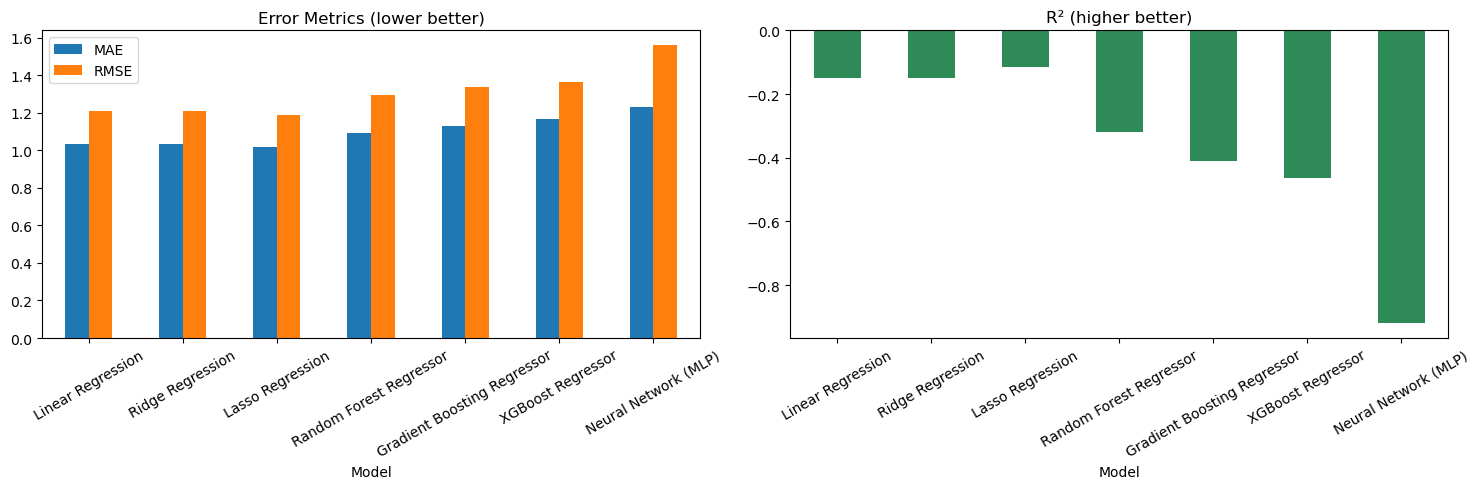

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5.Analysis Model Sesudah Cross-Validate

In [47]:
df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=10, mode='regression')
df_hasil_perbandingan.sort_values(by='R2-Score', ascending=False)

=== MENJALANKAN 10-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor
Menguji model: Neural Network (MLP)

Proses CV Selesai!


,Model,R2-Score,MAE,MSE,RMSE
3,Random Forest Regressor,-0.060384,1.126746,1.783592,1.335512
2,Lasso Regression,-0.071797,1.138832,1.815471,1.347394
1,Ridge Regression,-0.079070,1.130109,1.829684,1.352658
0,Linear Regression,-0.079633,1.129403,1.830490,1.352956
5,XGBoost Regressor,-0.139524,1.147546,1.907865,1.381255
4,Gradient Boosting Regressor,-0.152798,1.152993,1.924073,1.387110
6,Neural Network (MLP),-0.954051,1.422848,3.207525,1.790956


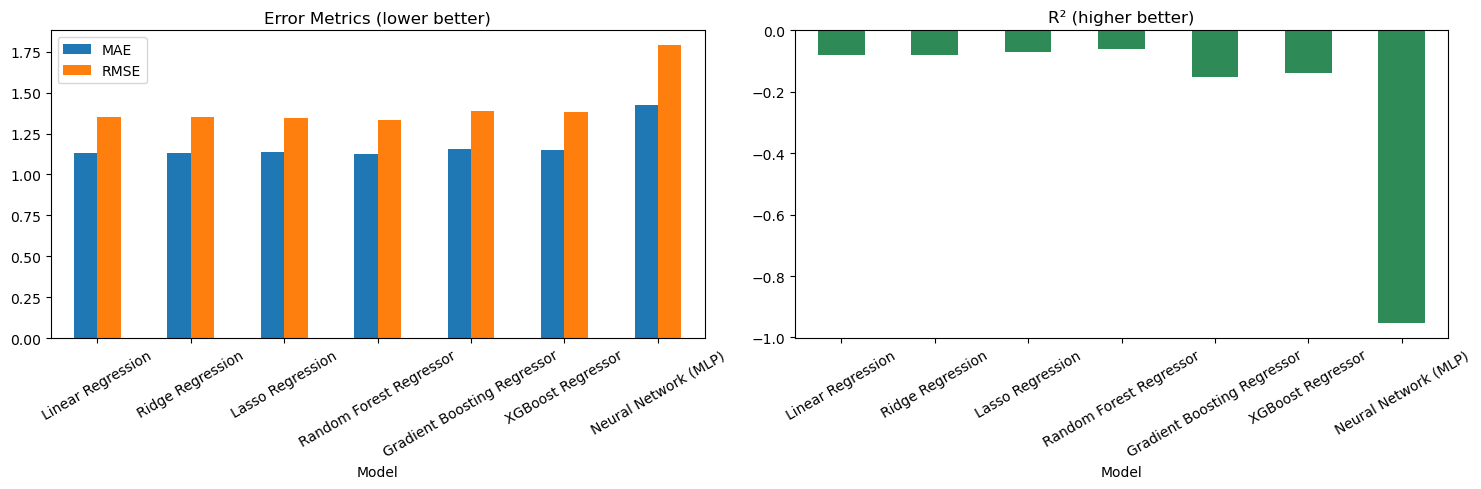

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_hasil_perbandingan.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_hasil_perbandingan.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
